# LoanIQ — Exploratory Data Analysis

This notebook documents the source dataset used in the Technofly Solutions internship project and the later portfolio rebuild. It intentionally separates **descriptive analysis** from model training. The production training pipeline lives in `backend/scripts/train.py`.

## 1. Load and validate the dataset

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA = Path('../data/raw/loan_applications.csv')
df = pd.read_csv(DATA)
print('shape:', df.shape)
df.head()

shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
required = {'Loan_ID','Loan_Status','Credit_History','LoanAmount','ApplicantIncome'}
assert required.issubset(df.columns)
assert len(df) == 614
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         614 non-null    int64  
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ KB


## 2. Missingness and target balance

The original notebook encoded some categorical missing values before dropping rows. The rebuild instead performs imputation **inside the ML pipeline** so validation folds cannot influence training preprocessing.

In [3]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Credit_History      50
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Gender              13
Married              3
dtype: int64

Loan_Status
Approved    422
Rejected    192
Name: count, dtype: int64
approval rate: 0.6873


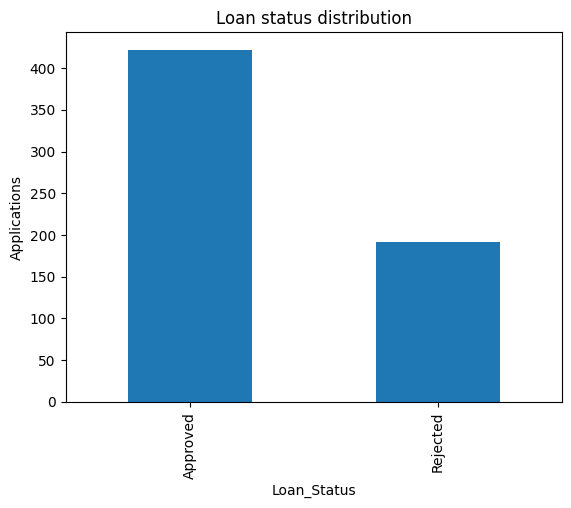

In [4]:
target = df['Loan_Status'].value_counts().rename(index={'Y':'Approved','N':'Rejected'})
print(target)
print('approval rate:', round((df['Loan_Status']=='Y').mean(), 4))
target.plot(kind='bar', title='Loan status distribution')
plt.ylabel('Applications')
plt.show()

## 3. Approval-rate slices

These are descriptive historical associations, not causal effects.

In [5]:
def approval_by(column):
    out = (df.assign(Approved=(df['Loan_Status']=='Y').astype(int))
             .groupby(column, dropna=False)['Approved']
             .agg(['count','mean'])
             .sort_values('mean', ascending=False))
    out['mean'] = (out['mean']*100).round(1)
    return out.rename(columns={'mean':'approval_rate_pct'})

approval_by('Credit_History')

,count,approval_rate_pct
Credit_History,,
1.0,475,79.6
NaN,50,74.0
0.0,89,7.9


In [6]:
approval_by('Property_Area')

,count,approval_rate_pct
Property_Area,,
Semiurban,233,76.8
Urban,202,65.8
Rural,179,61.5


In [7]:
approval_by('Education')

,count,approval_rate_pct
Education,,
Graduate,480,70.8
Not Graduate,134,61.2


## 4. Numeric distributions and engineered features

In [8]:
numeric = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']
df[numeric].describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0


In [9]:
engineered = df.copy()
engineered['TotalIncome'] = engineered['ApplicantIncome'] + engineered['CoapplicantIncome']
engineered['LogTotalIncome'] = np.log1p(engineered['TotalIncome'])
engineered['LogLoanAmount'] = np.log1p(engineered['LoanAmount'])
engineered['LoanToAnnualIncome'] = engineered['LoanAmount']*1000/(engineered['TotalIncome']*12).replace(0,np.nan)
engineered[['TotalIncome','LogTotalIncome','LogLoanAmount','LoanToAnnualIncome']].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalIncome,614.0,7024.705081,6458.663872,1442.000000,4166.000000,5416.500000,7521.750000,81000.000000
LogTotalIncome,614.0,8.669608,0.545017,7.274480,8.334952,8.597390,8.925682,11.302217
LogLoanAmount,592.0,4.866325,0.499861,2.302585,4.615121,4.859812,5.129899,6.552508
LoanToAnnualIncome,592.0,1.979640,0.691266,0.210243,1.609454,2.011593,2.345719,6.892637


## 5. Responsible-AI note

`Gender` exists in the source dataset but is **excluded from the rebuilt prediction feature set**. It is retained only for post-hoc slice auditing. Removing a sensitive column is not, by itself, proof of fairness because proxy variables and historical target bias may remain.

In [10]:
print('Gender missing:', df['Gender'].isna().sum())
approval_by('Gender')

Gender missing: 13


,count,approval_rate_pct
Gender,,
Male,489,69.3
Female,112,67.0
NaN,13,61.5


## 6. Next step

Run `python backend/scripts/train.py` from the repository root to reproduce the model benchmark, artifacts, fairness audit and deployed champion/challenger models.